<a href="https://colab.research.google.com/github/Palak1608/Data-Science-Lab-Work/blob/main/Intermediate_Project/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation using K-Means

In [19]:
from google.colab import files
uploaded = files.upload()

Saving store_customers.csv to store_customers (2).csv


In [20]:
import pandas as pd

df = pd.read_csv("store_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [21]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [22]:
df.isnull().sum()

,0
CustomerID,0
Gender,3
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [23]:
df = df.dropna()

## Data Preprocessing

In [24]:
from sklearn.preprocessing import StandardScaler

features = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

## Clustering using K-Means

In [25]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,1
1,1001,M,34.0,48.4,37.0,1
2,1002,F,40.0,70.5,26.0,0
3,1003,F,47.0,81.1,30.0,0
4,1004,F,33.0,42.1,58.0,4


## Cluster Analysis

In [26]:
df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,45.201005,82.093467,29.889447
1,36.261905,51.520748,47.176871
2,26.167513,28.469543,52.324873
3,66.695312,107.578125,4.984375
4,29.932927,33.126220,67.518293


In [27]:
df["Cluster"].value_counts()

,count
Cluster,
1,294
0,199
2,197
4,164
3,128


- The distribution of customers across clusters shows that some segments are larger, indicating dominant customer behavior patterns.

## Visualization

The following visualizations show how customers are grouped based on income, spending behavior, and age.

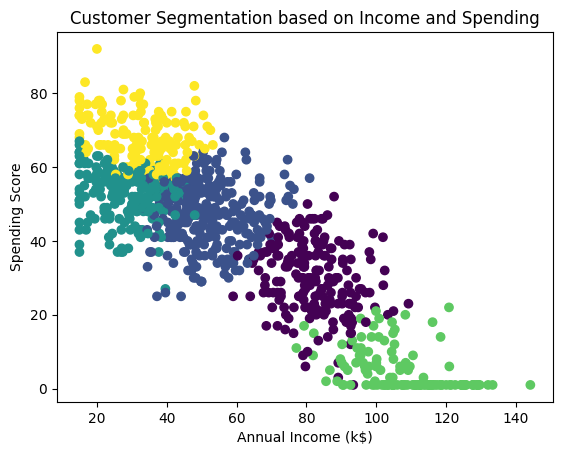

In [28]:
import matplotlib.pyplot as plt

plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=df["Cluster"])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation based on Income and Spending")
plt.show()

This graph shows how customers are grouped into different clusters based on their income and spending behavior.

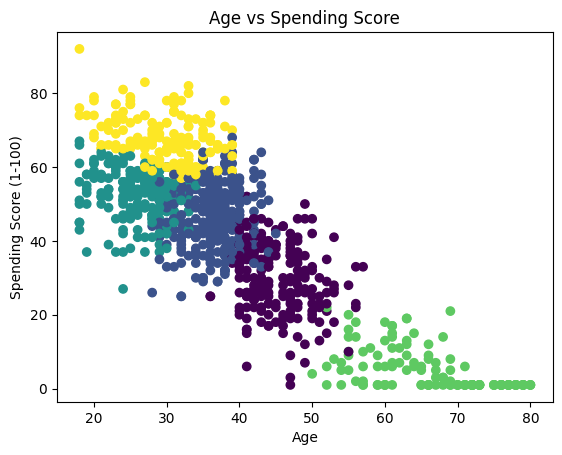

In [29]:
plt.scatter(df["Age"], df["Spending Score (1-100)"], c=df["Cluster"])
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.title("Age vs Spending Score")
plt.show()

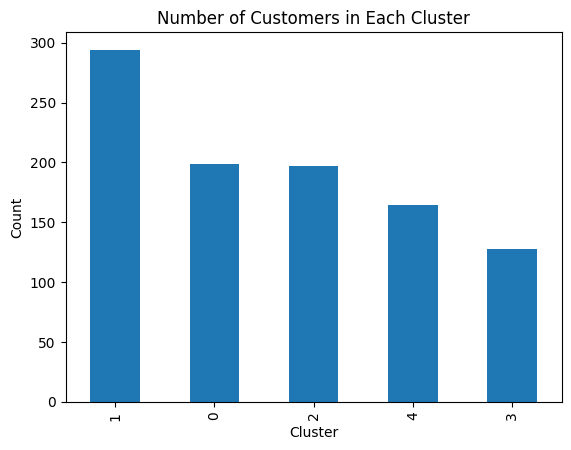

In [30]:
df["Cluster"].value_counts().plot(kind="bar", title="Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

## Insights

- The dataset was segmented into 5 distinct customer groups using K-Means clustering based on age, annual income, and spending score.

- A clear group of customers with **high income and high spending score** represents premium customers who are highly valuable for business revenue.

- Another cluster consists of **high income but low spending customers**, indicating a potential target group that can be encouraged to spend more through marketing strategies.

- A segment of **low income but high spending customers** suggests impulsive or deal-driven buyers who tend to spend despite lower income.

- Customers with **low income and low spending score** form a budget-conscious group with minimal contribution to sales.

- The relationship between age and spending shows that **younger customers generally have higher spending scores**, while older customers tend to spend more conservatively.

- The distribution of customers across clusters is uneven, indicating that certain customer behaviors are more dominant than others.

- Overall, the segmentation helps in identifying different customer types, enabling businesses to design targeted marketing and improve customer engagement.